# AUDIAX — STgram-MFN untuk Deteksi Anomali Suara Mesin (MIMII)


## 1. Setup

Impor, seed, dan pemilihan device supaya seluruh run bisa direproduksi.


In [1]:
from __future__ import annotations

import json
import math
import os
import random
import sys
import time
import warnings
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Optional, Sequence

import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"python      : {sys.version.split()[0]}")
print(f"torch       : {torch.__version__}")
print(f"torchaudio  : {torchaudio.__version__}")
print(f"device      : {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))


python      : 3.12.0
torch       : 2.6.0+cu126
torchaudio  : 2.6.0+cu126
device      : cuda (NVIDIA GeForce RTX 3050 Ti Laptop GPU)


## 2. Konfigurasi

Semua hyperparameter dikumpulkan di satu `dataclass` agar tidak ada angka yang muncul begitu saja.


In [2]:
@dataclass
class Config:
    dataset_dir: str = "Dataset"
    sample_rate: int = 16_000
    clip_seconds: float = 10.0
    audio_channel: Optional[int] = 0
    normalize_mode: str = "rms"

    val_frac: float = 0.10
    test_frac: float = 0.20
    split_seed: int = 42

    n_fft: int = 1024
    hop_length: int = 512
    win_length: int = 1024
    n_mels: int = 128
    use_tgram: bool = True
    use_linear_branch: bool = True

    aug_time_shift: bool = True
    aug_gain_db: float = 3.0
    spec_freq_mask: int = 16
    spec_time_mask: int = 32

    emb_dim: int = 128
    width_mult: float = 1.0
    block_strides: tuple = ((2, 2), (1, 2), (1, 1), (1, 2), (1, 1))

    margin_type: str = "arcface"
    arcface_scale: float = 30.0
    arcface_margin: float = 0.7
    n_subcenters: int = 3
    n_pseudo_clusters: int = 1

    epochs: int = 60
    batch_size: int = 32
    lr: float = 3e-4
    weight_decay: float = 1e-2
    warmup_epochs: int = 3
    patience: int = 15
    amp: bool = True
    num_workers: int = 0
    cache_audio: bool = True

    n_calib_clips: int = 200
    knn_k: int = 4
    shrinkage: float = 0.1
    backends: tuple = ("cosine", "knn", "maha")
    fusion: str = "min"

    dcase_dir: str = "fan"


CFG = Config()
RUN_TAG = "stgram_mfn"

_ch = 1 + int(CFG.use_tgram) + int(CFG.use_linear_branch)
print(f"Kanal input CNN : {_ch}  "
      f"(sgram{'+tgram' if CFG.use_tgram else ''}{'+linear' if CFG.use_linear_branch else ''})")
print(f"Bentuk input    : ({_ch}, {CFG.n_mels}, "
      f"{int(CFG.sample_rate * CFG.clip_seconds) // CFG.hop_length + 1})")
print(f"Head            : {CFG.margin_type} "
      f"(s={CFG.arcface_scale}, m={CFG.arcface_margin}, sub-center={CFG.n_subcenters})")


Kanal input CNN : 3  (sgram+tgram+linear)
Bentuk input    : (3, 128, 313)
Head            : arcface (s=30.0, m=0.7, sub-center=3)


## 3. Penemuan dataset & pembagian train/val/test

Manifest dipindai dari `Dataset/` lalu dibagi train/val/test per unit, dengan seluruh klip abnormal masuk test.


In [3]:
def find_repo_root(start: Optional[Path] = None) -> Path:
    cur = (start or Path.cwd()).resolve()
    for cand in [cur, *cur.parents]:
        if (cand / "CLAUDE.md").exists() and (cand / "ai").is_dir():
            return cand
    return cur


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / CFG.dataset_dir
print(f"repo  : {REPO_ROOT}")
print(f"data  : {DATA_ROOT}")

if not DATA_ROOT.is_dir():
    raise FileNotFoundError(
        f"Folder dataset tidak ditemukan: {DATA_ROOT}\n"
        f"Isi {REPO_ROOT}: {sorted(p.name for p in REPO_ROOT.iterdir())}"
    )


def build_manifest(root: Path) -> pd.DataFrame:
    rows = []
    for unit_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        for label_name, is_anomaly in (("normal", 0), ("abnormal", 1)):
            sub = unit_dir / label_name
            if not sub.is_dir():
                continue
            for wav in sorted(sub.glob("*.wav")):
                rows.append({
                    "path": str(wav),
                    "unit": unit_dir.name,
                    "label": label_name,
                    "is_anomaly": is_anomaly,
                })
    df = pd.DataFrame(rows)
    assert len(df), f"Tidak ada .wav di {root}"
    return df


MANIFEST = build_manifest(DATA_ROOT)
UNITS = sorted(MANIFEST["unit"].unique())

print(f"\nTotal klip : {len(MANIFEST)}   |   unit: {UNITS}")
display(MANIFEST.pivot_table(index="unit", columns="label", values="path",
                             aggfunc="count").fillna(0).astype(int))


repo  : C:\Users\Frederick\audiax_model
data  : C:\Users\Frederick\audiax_model\Dataset

Total klip : 2950   |   unit: ['id_00', 'id_02', 'id_04', 'id_06']


label,abnormal,normal
unit,,
id_00,407,407
id_02,359,359
id_04,348,348
id_06,361,361


In [4]:
def split_manifest(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    rng = np.random.default_rng(cfg.split_seed)
    df = df.copy()
    df["split"] = "test"

    for unit in sorted(df["unit"].unique()):
        idx = df.index[(df["unit"] == unit) & (df["is_anomaly"] == 0)].to_numpy()
        rng.shuffle(idx)
        n = len(idx)
        n_test = int(round(n * cfg.test_frac))
        n_val = int(round(n * cfg.val_frac))
        df.loc[idx[:n_test], "split"] = "test"
        df.loc[idx[n_test:n_test + n_val], "split"] = "val"
        df.loc[idx[n_test + n_val:], "split"] = "train"

    return df


SPLIT = split_manifest(MANIFEST, CFG)

TRAIN_DF = SPLIT[SPLIT["split"] == "train"].reset_index(drop=True)
VAL_DF = SPLIT[SPLIT["split"] == "val"].reset_index(drop=True)
TEST_DF = SPLIT[SPLIT["split"] == "test"].reset_index(drop=True)

assert (TRAIN_DF["is_anomaly"] == 0).all(), "BOCOR: ada klip abnormal di split train!"
assert (VAL_DF["is_anomaly"] == 0).all(), "BOCOR: ada klip abnormal di split val!"
assert len(set(TRAIN_DF["path"]) & set(TEST_DF["path"])) == 0, "BOCOR: klip train muncul di test!"

print(f"train : {len(TRAIN_DF):4d} klip (normal saja)")
print(f"val   : {len(VAL_DF):4d} klip (normal saja, untuk memilih epoch)")
print(f"test  : {len(TEST_DF):4d} klip "
      f"({(TEST_DF['is_anomaly'] == 0).sum()} normal + {(TEST_DF['is_anomaly'] == 1).sum()} abnormal)")
display(SPLIT.pivot_table(index="unit", columns=["split", "label"], values="path",
                          aggfunc="count").fillna(0).astype(int))


train : 1032 klip (normal saja)
val   :  148 klip (normal saja, untuk memilih epoch)
test  : 1770 klip (295 normal + 1475 abnormal)


split     test         train    val
label abnormal normal normal normal
unit                               
id_00      407     81    285     41
id_02      359     72    251     36
id_04      348     70    243     35
id_06      361     72    253     36

## 4. Pembacaan audio & augmentasi

Audio dibaca mono pada channel dan normalisasi RMS yang konsisten, dengan augmentasi hanya aktif saat training.


In [5]:
CLIP_LEN = int(CFG.sample_rate * CFG.clip_seconds)


def load_wave(path: str, cfg: Config) -> np.ndarray:
    wav, sr = sf.read(path, dtype="float32", always_2d=True)
    if cfg.audio_channel is None:
        wav = wav.mean(axis=1)
    else:
        wav = wav[:, min(cfg.audio_channel, wav.shape[1] - 1)]

    if sr != cfg.sample_rate:
        wav = torchaudio.functional.resample(
            torch.from_numpy(wav), sr, cfg.sample_rate).numpy()

    if len(wav) < CLIP_LEN:
        wav = np.tile(wav, int(np.ceil(CLIP_LEN / len(wav))))
    wav = wav[:CLIP_LEN]

    if cfg.normalize_mode == "rms":
        wav = wav / (np.sqrt(np.mean(wav ** 2)) + 1e-8)
    elif cfg.normalize_mode == "peak":
        wav = wav / (np.abs(wav).max() + 1e-8)
    return wav.astype(np.float32)


class ClipDataset(torch.utils.data.Dataset):

    def __init__(self, df: pd.DataFrame, cfg: Config, train: bool = False,
                 labels: Optional[np.ndarray] = None):
        self.paths = df["path"].tolist()
        self.cfg = cfg
        self.train = train
        self.labels = (np.zeros(len(df), dtype=np.int64) if labels is None
                       else np.asarray(labels, dtype=np.int64))
        self.is_anomaly = df["is_anomaly"].to_numpy()
        self.unit = df["unit"].to_numpy()
        self._cache: Optional[np.ndarray] = None
        if cfg.cache_audio:
            self._cache = np.stack(
                [load_wave(p, cfg).astype(np.float16) for p in self.paths])

    def __len__(self) -> int:
        return len(self.paths)

    def _augment(self, wav: np.ndarray) -> np.ndarray:
        if self.cfg.aug_time_shift:
            wav = np.roll(wav, np.random.randint(len(wav)))
        if self.cfg.aug_gain_db > 0:
            gain = 10 ** (np.random.uniform(-self.cfg.aug_gain_db, self.cfg.aug_gain_db) / 20)
            wav = wav * gain
        return wav

    def __getitem__(self, i: int):
        wav = (self._cache[i].astype(np.float32) if self._cache is not None
               else load_wave(self.paths[i], self.cfg))
        if self.train:
            wav = self._augment(wav)
        return torch.from_numpy(np.ascontiguousarray(wav)), int(self.labels[i])


_probe = load_wave(TRAIN_DF["path"].iloc[0], CFG)
print(f"Contoh gelombang: shape={_probe.shape}  rms={np.sqrt((_probe ** 2).mean()):.4f}  "
      f"min={_probe.min():.2f}  max={_probe.max():.2f}")


Contoh gelombang: shape=(160000,)  rms=1.0000  min=-4.47  max=4.11


## 5. Ruang label MAC

Model dilatih menebak identitas unit mesin (bukan sehat/rusak) sebagai proksi pendekatan first-shot ASD.


In [6]:
def build_label_space(train_df: pd.DataFrame, val_df: pd.DataFrame, cfg: Config):
    units = sorted(train_df["unit"].unique())
    unit_to_idx = {u: i for i, u in enumerate(units)}

    if cfg.n_pseudo_clusters <= 1:
        n_classes = len(units)
        y_tr = train_df["unit"].map(unit_to_idx).to_numpy()
        y_va = val_df["unit"].map(unit_to_idx).to_numpy()
        return y_tr, y_va, n_classes, units, None

    mel = torchaudio.transforms.MelSpectrogram(
        sample_rate=cfg.sample_rate, n_fft=cfg.n_fft, hop_length=cfg.hop_length,
        win_length=cfg.win_length, n_mels=cfg.n_mels, power=2.0)

    def feats(df: pd.DataFrame) -> np.ndarray:
        out = []
        for p in df["path"]:
            m = torch.log(mel(torch.from_numpy(load_wave(p, cfg))) + 1e-8)
            out.append(torch.cat([m.mean(-1), m.std(-1)]).numpy())
        return np.stack(out)

    X_tr, X_va = feats(train_df), feats(val_df)
    y_tr = np.zeros(len(train_df), dtype=np.int64)
    y_va = np.zeros(len(val_df), dtype=np.int64)
    kmeans_per_unit = {}

    for u, ui in unit_to_idx.items():
        m_tr = (train_df["unit"] == u).to_numpy()
        km = KMeans(n_clusters=cfg.n_pseudo_clusters, n_init=10,
                    random_state=cfg.split_seed).fit(X_tr[m_tr])
        kmeans_per_unit[u] = km
        y_tr[m_tr] = ui * cfg.n_pseudo_clusters + km.labels_
        m_va = (val_df["unit"] == u).to_numpy()
        if m_va.any():
            y_va[m_va] = ui * cfg.n_pseudo_clusters + km.predict(X_va[m_va])

    return y_tr, y_va, len(units) * cfg.n_pseudo_clusters, units, kmeans_per_unit


Y_TRAIN, Y_VAL, N_CLASSES, UNIT_ORDER, KMEANS = build_label_space(TRAIN_DF, VAL_DF, CFG)
UNIT_TO_IDX = {u: i for i, u in enumerate(UNIT_ORDER)}

print(f"Kelas MAC : {N_CLASSES}  "
      f"({len(UNIT_ORDER)} unit x {CFG.n_pseudo_clusters} pseudo-cluster)")
print("Sebaran label train:", np.bincount(Y_TRAIN, minlength=N_CLASSES).tolist())


Kelas MAC : 4  (4 unit x 1 pseudo-cluster)
Sebaran label train: [285, 251, 243, 253]


## 6. Front-end ganda: Sgram + Tgram (+ Linear)

Spektrogram log-mel digabung dengan TgramNet yang belajar dari gelombang mentah, plus cabang linear opsional untuk resolusi frekuensi tinggi.


In [7]:
class TgramNet(nn.Module):

    def __init__(self, n_mels: int, win_length: int, hop_length: int, n_layers: int = 3):
        super().__init__()
        self.extractor = nn.Conv1d(1, n_mels, win_length, hop_length,
                                   padding=win_length // 2, bias=False)
        self.encoder = nn.Sequential(*[
            nn.Sequential(
                nn.BatchNorm1d(n_mels),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Conv1d(n_mels, n_mels, 3, 1, 1, bias=False),
            ) for _ in range(n_layers)
        ])

    def forward(self, wav: torch.Tensor) -> torch.Tensor:
        return self.encoder(self.extractor(wav.unsqueeze(1)))


class DualFrontEnd(nn.Module):

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.mel = torchaudio.transforms.MelSpectrogram(
            sample_rate=cfg.sample_rate, n_fft=cfg.n_fft, hop_length=cfg.hop_length,
            win_length=cfg.win_length, n_mels=cfg.n_mels, power=2.0, center=True)
        self.tgram = TgramNet(cfg.n_mels, cfg.win_length, cfg.hop_length) if cfg.use_tgram else None
        if cfg.use_linear_branch:
            self.spec = torchaudio.transforms.Spectrogram(
                n_fft=cfg.n_fft, hop_length=cfg.hop_length,
                win_length=cfg.win_length, power=2.0, center=True)
            self.freq_pool = nn.AdaptiveAvgPool1d(cfg.n_mels)
        self.n_channels = 1 + int(cfg.use_tgram) + int(cfg.use_linear_branch)
        self.in_norm = nn.BatchNorm2d(self.n_channels)
        self.freq_mask = torchaudio.transforms.FrequencyMasking(cfg.spec_freq_mask)
        self.time_mask = torchaudio.transforms.TimeMasking(cfg.spec_time_mask)

    def forward(self, wav: torch.Tensor, augment: bool = False) -> torch.Tensor:
        with torch.autocast(wav.device.type, enabled=False):
            wav = wav.float()
            chans = [torch.log(self.mel(wav) + 1e-8)]
            if self.tgram is not None:
                chans.append(self.tgram(wav))
            if self.cfg.use_linear_branch:
                lin = torch.log(self.spec(wav) + 1e-8)
                chans.append(self.freq_pool(lin.transpose(1, 2)).transpose(1, 2))
            x = self.in_norm(torch.stack(chans, dim=1))
            if augment:
                x = self.time_mask(self.freq_mask(x))
        return x


_fe = DualFrontEnd(CFG).to(DEVICE).eval()
with torch.no_grad():
    _out = _fe(torch.from_numpy(_probe)[None].to(DEVICE))
FEAT_SHAPE = tuple(_out.shape[1:])
print(f"Bentuk keluaran front-end : {tuple(_out.shape)}  -> (C, n_mels, T) = {FEAT_SHAPE}")
print(f"Parameter front-end       : {sum(p.numel() for p in _fe.parameters()):,}")
del _fe, _out


Bentuk keluaran front-end : (1, 3, 128, 313)  -> (C, n_mels, T) = (3, 128, 313)
Parameter front-end       : 279,302


## 7. Backbone: MobileFaceNet

Backbone MobileFaceNet dipakai dengan pola stride yang disesuaikan agar resolusi frekuensi tetap terjaga untuk suara mesin.


In [8]:
class ConvBlock(nn.Module):

    def __init__(self, cin: int, cout: int, k, s=1, p=0, groups: int = 1, linear: bool = False):
        super().__init__()
        self.conv = nn.Conv2d(cin, cout, k, s, p, groups=groups, bias=False)
        self.bn = nn.BatchNorm2d(cout)
        self.act = None if linear else nn.PReLU(cout)

    def forward(self, x):
        x = self.bn(self.conv(x))
        return x if self.act is None else self.act(x)


class Bottleneck(nn.Module):

    def __init__(self, cin: int, cout: int, stride, expansion: int):
        super().__init__()
        stride = (stride, stride) if isinstance(stride, int) else tuple(stride)
        hidden = cin * expansion
        self.block = nn.Sequential(
            ConvBlock(cin, hidden, 1),
            ConvBlock(hidden, hidden, 3, stride, 1, groups=hidden),
            ConvBlock(hidden, cout, 1, linear=True),
        )
        self.use_res = stride == (1, 1) and cin == cout

    def forward(self, x):
        out = self.block(x)
        return x + out if self.use_res else out


class MobileFaceNet(nn.Module):

    CFG_BLOCKS = ((2, 64, 5), (4, 128, 1), (2, 128, 6), (4, 128, 1), (2, 128, 2))

    def __init__(self, in_ch: int, emb_dim: int = 128, input_hw=(128, 313),
                 width: float = 1.0, strides=None):
        super().__init__()
        w = lambda n: max(8, int(round(n * width)))
        strides = strides or ((2, 2), (2, 2), (1, 1), (2, 2), (1, 1))
        assert len(strides) == len(self.CFG_BLOCKS), "block_strides harus 5 tahap"
        self.stem = ConvBlock(in_ch, w(64), 3, 2, 1)
        self.dw = ConvBlock(w(64), w(64), 3, 1, 1, groups=w(64))

        layers, cin = [], w(64)
        for (expansion, cout, repeat), stride in zip(self.CFG_BLOCKS, strides):
            cout = w(cout)
            for i in range(repeat):
                layers.append(Bottleneck(cin, cout, stride if i == 0 else 1, expansion))
                cin = cout
        self.blocks = nn.Sequential(*layers)
        self.conv_sep = ConvBlock(cin, w(512), 1)

        was_training = self.training
        self.eval()
        with torch.no_grad():
            h, w_ = self.conv_sep(self.blocks(self.dw(self.stem(
                torch.zeros(1, in_ch, *input_hw))))).shape[-2:]
        self.train(was_training)

        self.gdconv = ConvBlock(w(512), w(512), (h, w_), groups=w(512), linear=True)
        self.proj = ConvBlock(w(512), emb_dim, 1, linear=True)
        self.feature_map_hw = (h, w_)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_sep(self.blocks(self.dw(self.stem(x))))
        return self.proj(self.gdconv(x)).flatten(1)


_bb = MobileFaceNet(FEAT_SHAPE[0], CFG.emb_dim, FEAT_SHAPE[1:], CFG.width_mult, CFG.block_strides)
print(f"Stride tiap tahap (freq, waktu) : {CFG.block_strides}")
print(f"Peta fitur sebelum GDConv      : {_bb.feature_map_hw}  (freq x waktu)")
print(f"Parameter backbone             : {sum(p.numel() for p in _bb.parameters()):,}")
del _bb


Stride tiap tahap (freq, waktu) : ((2, 2), (1, 2), (1, 1), (1, 2), (1, 1))
Peta fitur sebelum GDConv      : (32, 20)  (freq x waktu)
Parameter backbone             : 1,305,728


## 8. Head: Sub-Center ArcFace / CosFace

Head margin sudut sub-center mendorong kelas saling menjauh sehingga tersedia ruang untuk skor anomali.


In [9]:
class SubCenterMargin(nn.Module):

    def __init__(self, emb_dim: int, n_classes: int, scale: float = 30.0,
                 margin: float = 0.7, n_subcenters: int = 3, margin_type: str = "arcface"):
        super().__init__()
        self.n_classes, self.k = n_classes, n_subcenters
        self.scale, self.margin, self.margin_type = scale, margin, margin_type
        self.weight = nn.Parameter(torch.empty(n_classes * n_subcenters, emb_dim))
        nn.init.xavier_uniform_(self.weight)
        self.cos_m, self.sin_m = math.cos(margin), math.sin(margin)
        self.th = math.cos(math.pi - margin)
        self.mm = math.sin(math.pi - margin) * margin

    def cosine(self, emb: torch.Tensor) -> torch.Tensor:
        cos = F.linear(F.normalize(emb.float()), F.normalize(self.weight.float()))
        return cos.view(-1, self.n_classes, self.k).max(dim=2).values

    def class_centers(self) -> torch.Tensor:
        return F.normalize(self.weight).view(self.n_classes, self.k, -1)

    def forward(self, emb: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        with torch.autocast(emb.device.type, enabled=False):
            cos = self.cosine(emb).clamp(-1 + 1e-6, 1 - 1e-6)
            one_hot = F.one_hot(labels, self.n_classes).to(cos.dtype)

            if self.margin_type == "cosface":
                target = cos - self.margin
            else:
                sin = torch.sqrt((1.0 - cos.pow(2)).clamp_min(1e-9))
                target = cos * self.cos_m - sin * self.sin_m
                target = torch.where(cos > self.th, target, cos - self.mm)

            return self.scale * (one_hot * target + (1.0 - one_hot) * cos)


class STgramMFN(nn.Module):

    def __init__(self, cfg: Config, n_classes: int, input_hw):
        super().__init__()
        self.cfg = cfg
        self.frontend = DualFrontEnd(cfg)
        self.backbone = MobileFaceNet(self.frontend.n_channels, cfg.emb_dim,
                                      input_hw, cfg.width_mult, cfg.block_strides)
        self.head = SubCenterMargin(cfg.emb_dim, n_classes, cfg.arcface_scale,
                                    cfg.arcface_margin, cfg.n_subcenters, cfg.margin_type)

    def embed(self, wav: torch.Tensor, augment: bool = False) -> torch.Tensor:
        return self.backbone(self.frontend(wav, augment=augment))

    def forward(self, wav: torch.Tensor, labels: torch.Tensor, augment: bool = False):
        emb = self.embed(wav, augment=augment)
        return self.head(emb, labels), emb


MODEL = STgramMFN(CFG, N_CLASSES, FEAT_SHAPE[1:]).to(DEVICE)
_n_par = sum(p.numel() for p in MODEL.parameters())
print(f"Total parameter : {_n_par:,}  (~{_n_par * 4 / 1e6:.1f} MB float32)")
print(f"Embedding       : {CFG.emb_dim}-d   |   kelas MAC: {N_CLASSES} x "
      f"{CFG.n_subcenters} sub-pusat")


Total parameter : 1,586,566  (~6.3 MB float32)
Embedding       : 128-d   |   kelas MAC: 4 x 3 sub-pusat


## 9. Training

Model dilatih dengan AdamW, warmup, dan cosine annealing, dengan epoch dipilih dari val loss MAC.


In [10]:
def make_loader(dataset: ClipDataset, cfg: Config, shuffle: bool) -> torch.utils.data.DataLoader:
    return torch.utils.data.DataLoader(
        dataset, batch_size=cfg.batch_size, shuffle=shuffle,
        num_workers=cfg.num_workers, pin_memory=(DEVICE.type == "cuda"),
        drop_last=shuffle and len(dataset) > cfg.batch_size)


def lr_lambda_factory(cfg: Config):
    def fn(epoch: int) -> float:
        if epoch < cfg.warmup_epochs:
            return (epoch + 1) / max(1, cfg.warmup_epochs)
        prog = (epoch - cfg.warmup_epochs) / max(1, cfg.epochs - cfg.warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * min(prog, 1.0)))
    return fn


def run_epoch(model, loader, cfg, optimizer=None, scaler=None):
    train = optimizer is not None
    model.train(train)
    tot_loss, tot_correct, tot_n = 0.0, 0, 0

    for wav, y in loader:
        wav, y = wav.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        with torch.set_grad_enabled(train):
            with torch.autocast(DEVICE.type, dtype=torch.float16,
                                enabled=cfg.amp and DEVICE.type == "cuda"):
                logits, _ = model(wav, y, augment=train)
                loss = F.cross_entropy(logits, y)
        if train:
            optimizer.zero_grad(set_to_none=True)
            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

        bs = y.size(0)
        tot_loss += loss.item() * bs
        tot_correct += (logits.argmax(1) == y).sum().item()
        tot_n += bs

    return tot_loss / tot_n, tot_correct / tot_n


def train_model(model, cfg: Config, train_ds, val_ds):
    set_seed(cfg.split_seed)
    train_loader = make_loader(train_ds, cfg, shuffle=True)
    val_loader = make_loader(val_ds, cfg, shuffle=False)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda_factory(cfg))
    scaler = (torch.amp.GradScaler(DEVICE.type)
              if cfg.amp and DEVICE.type == "cuda" else None)

    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
    best = {"val_loss": float("inf"), "epoch": 0, "state": None}
    t0 = time.time()

    for epoch in range(1, cfg.epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, cfg, optimizer, scaler)
        va_loss, va_acc = run_epoch(model, val_loader, cfg)
        scheduler.step()

        hist["train_loss"].append(tr_loss); hist["train_acc"].append(tr_acc)
        hist["val_loss"].append(va_loss);   hist["val_acc"].append(va_acc)
        hist["lr"].append(optimizer.param_groups[0]["lr"])

        flag = ""
        if va_loss < best["val_loss"] - 1e-4:
            best.update(val_loss=va_loss, epoch=epoch,
                        state={k: v.detach().cpu().clone() for k, v in model.state_dict().items()})
            flag = "  <- terbaik"
        print(f"epoch {epoch:3d}/{cfg.epochs} | train {tr_loss:7.4f} acc {tr_acc:.3f} "
              f"| val {va_loss:7.4f} acc {va_acc:.3f} "
              f"| lr {optimizer.param_groups[0]['lr']:.2e} | {time.time() - t0:5.0f}s{flag}")

        if epoch - best["epoch"] >= cfg.patience:
            print(f"Early stopping: {cfg.patience} epoch tanpa perbaikan val loss.")
            break

    model.load_state_dict(best["state"])
    print(f"\nSelesai dalam {time.time() - t0:.0f}s. Checkpoint dipakai: epoch {best['epoch']} "
          f"(val loss {best['val_loss']:.4f}).")
    return model, hist, best["epoch"]


TRAIN_DS = ClipDataset(TRAIN_DF, CFG, train=True, labels=Y_TRAIN)
VAL_DS = ClipDataset(VAL_DF, CFG, train=False, labels=Y_VAL)
print(f"Cache audio siap: train={len(TRAIN_DS)} val={len(VAL_DS)} klip\n")

MODEL, HIST, BEST_EPOCH = train_model(MODEL, CFG, TRAIN_DS, VAL_DS)


Cache audio siap: train=1032 val=148 klip

epoch   1/60 | train 21.1690 acc 0.000 | val 21.2206 acc 0.000 | lr 2.00e-04 |   186s  <- terbaik
epoch   2/60 | train 17.4217 acc 0.001 | val 10.2854 acc 0.216 | lr 3.00e-04 |   339s  <- terbaik
epoch   3/60 | train  3.3593 acc 0.602 | val  0.0872 acc 0.993 | lr 3.00e-04 |   424s  <- terbaik
epoch   4/60 | train  0.2860 acc 0.967 | val  0.0660 acc 0.993 | lr 3.00e-04 |   444s  <- terbaik
epoch   5/60 | train  0.0546 acc 0.988 | val  0.0004 acc 1.000 | lr 2.99e-04 |   464s  <- terbaik
epoch   6/60 | train  0.0560 acc 0.987 | val  0.0157 acc 0.993 | lr 2.98e-04 |   484s
epoch   7/60 | train  0.0401 acc 0.992 | val  0.0824 acc 0.993 | lr 2.96e-04 |   504s
epoch   8/60 | train  0.0486 acc 0.994 | val  0.0001 acc 1.000 | lr 2.94e-04 |   524s  <- terbaik
epoch   9/60 | train  0.0522 acc 0.992 | val  0.1106 acc 0.993 | lr 2.92e-04 |   544s
epoch  10/60 | train  0.1410 acc 0.985 | val  0.0001 acc 1.000 | lr 2.89e-04 |   564s
epoch  11/60 | train  0.0

## 10. Ekstraksi embedding

Seluruh bobot dibekukan dan embedding dihitung dalam mode inferensi tanpa augmentasi.


In [11]:
@torch.inference_mode()
def extract_embeddings(model, df: pd.DataFrame, cfg: Config) -> np.ndarray:
    model.eval()
    ds = ClipDataset(df, cfg, train=False)
    loader = make_loader(ds, cfg, shuffle=False)
    out = []
    for wav, _ in loader:
        with torch.autocast(DEVICE.type, dtype=torch.float16,
                            enabled=cfg.amp and DEVICE.type == "cuda"):
            emb = model.embed(wav.to(DEVICE), augment=False)
        out.append(F.normalize(emb.float()).cpu().numpy())
    return np.concatenate(out)


_n_calib = min(CFG.n_calib_clips, int(TRAIN_DF.groupby("unit").size().min()))
CALIB_DF = (TRAIN_DF.groupby("unit", group_keys=False)
            .sample(n=_n_calib, random_state=CFG.split_seed)
            .reset_index(drop=True))
print(f"Memory bank : {_n_calib} klip/unit")

t0 = time.time()
EMB_CALIB = extract_embeddings(MODEL, CALIB_DF, CFG)
EMB_TEST = extract_embeddings(MODEL, TEST_DF, CFG)
print(f"Embedding kalibrasi : {EMB_CALIB.shape}")
print(f"Embedding test      : {EMB_TEST.shape}   ({time.time() - t0:.0f}s)")


Memory bank : 200 klip/unit
Embedding kalibrasi : (800, 128)
Embedding test      : (1770, 128)   (25s)


## 11. Skor anomali: empat backend, fusi minimum

Skor anomali dihitung dari beberapa backend yang di-z-normalisasi lalu difusi dengan minimum.


In [12]:
def _cos_dist(query: np.ndarray, bank: np.ndarray) -> np.ndarray:
    return 1.0 - query @ bank.T


def compute_backend_scores(query: np.ndarray, bank: np.ndarray, cfg: Config,
                           leave_one_out: bool = False,
                           centers: Optional[np.ndarray] = None) -> dict:
    scores = {}
    dist = _cos_dist(query, bank)
    if leave_one_out:
        np.fill_diagonal(dist, np.inf)

    if "cosine" in cfg.backends:
        scores["cosine"] = dist.min(axis=1)
    if "knn" in cfg.backends:
        k = min(cfg.knn_k, bank.shape[0] - int(leave_one_out))
        scores["knn"] = np.sort(dist, axis=1)[:, :k].mean(axis=1)
    if "maha" in cfg.backends:
        mu = bank.mean(axis=0)
        cov = np.cov(bank, rowvar=False)
        cov = (1 - cfg.shrinkage) * cov + cfg.shrinkage * np.eye(len(mu)) * np.trace(cov) / len(mu)
        inv = np.linalg.pinv(cov)
        d = query - mu
        scores["maha"] = np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", d, inv, d), 0.0))
    if "center" in cfg.backends and centers is not None:
        scores["center"] = 1.0 - (query @ centers.T).max(axis=1)
    return scores


def fit_calibration(bank: np.ndarray, cfg: Config,
                    centers: Optional[np.ndarray] = None) -> dict:
    raw = compute_backend_scores(bank, bank, cfg, leave_one_out=True, centers=centers)
    return {name: {"mean": float(v.mean()), "std": float(v.std() + 1e-8)}
            for name, v in raw.items()}


def score_clips(query: np.ndarray, bank: np.ndarray, stats: dict, cfg: Config,
                centers: Optional[np.ndarray] = None, leave_one_out: bool = False):
    raw = compute_backend_scores(query, bank, cfg, leave_one_out=leave_one_out, centers=centers)
    z = {n: (v - stats[n]["mean"]) / stats[n]["std"] for n, v in raw.items()}
    stacked = np.stack([z[n] for n in sorted(z)], axis=0)
    fused = stacked.min(axis=0) if cfg.fusion == "min" else stacked.mean(axis=0)
    return z, fused


print("Backend aktif :", ", ".join(CFG.backends))
print("Fusi          :", CFG.fusion.upper(),
      "(konservatif -- semua backend harus sepakat)")


Backend aktif : cosine, knn, maha
Fusi          : MIN (konservatif -- semua backend harus sepakat)


## 12. Evaluasi: AUC & pAUC (p = 0.1)

Evaluasi dilakukan per unit terhadap bank kalibrasinya sendiri memakai metrik AUC dan pAUC.


In [13]:
def auc_pauc(y_true: np.ndarray, scores: np.ndarray, p: float = 0.1):
    if len(np.unique(y_true)) < 2:
        return float("nan"), float("nan")
    return (float(roc_auc_score(y_true, scores)),
            float(roc_auc_score(y_true, scores, max_fpr=p)))


def evaluate(model, calib_df, emb_calib, test_df, emb_test, cfg: Config,
             head_centers: Optional[np.ndarray] = None,
             unit_to_class: Optional[dict] = None) -> tuple:
    per_unit, per_backend, keep = [], [], {}

    for unit in sorted(test_df["unit"].unique()):
        bank = emb_calib[(calib_df["unit"] == unit).to_numpy()]
        m_test = (test_df["unit"] == unit).to_numpy()
        query, y = emb_test[m_test], test_df.loc[m_test, "is_anomaly"].to_numpy()
        if bank.shape[0] < 5 or len(np.unique(y)) < 2:
            continue

        centers = None
        if head_centers is not None and unit_to_class is not None and unit in unit_to_class:
            centers = np.concatenate([head_centers[c] for c in unit_to_class[unit]])

        stats = fit_calibration(bank, cfg, centers=centers)
        z, fused = score_clips(query, bank, stats, cfg, centers=centers)

        auc, pauc = auc_pauc(y, fused)
        per_unit.append({"unit": unit, "n_normal": int((y == 0).sum()),
                         "n_abnormal": int((y == 1).sum()),
                         "auc": auc, "pauc": pauc})
        for name, zv in z.items():
            a, pa = auc_pauc(y, zv)
            per_backend.append({"unit": unit, "backend": name, "auc": a, "pauc": pa})
        keep[unit] = {"y": y, "fused": fused, "z": z}

    unit_df = pd.DataFrame(per_unit)
    backend_df = pd.DataFrame(per_backend)
    return unit_df, backend_df, keep


def hmean(x) -> float:
    x = np.asarray([v for v in x if np.isfinite(v) and v > 0])
    return float(len(x) / np.sum(1.0 / x)) if len(x) else float("nan")


UNIT_TO_CLASSES = {
    u: [UNIT_TO_IDX[u] * CFG.n_pseudo_clusters + j for j in range(CFG.n_pseudo_clusters)]
    for u in UNIT_ORDER
}
HEAD_CENTERS = MODEL.head.class_centers().detach().cpu().numpy()

UNIT_RES, BACKEND_RES, RAW_SCORES = evaluate(
    MODEL, CALIB_DF, EMB_CALIB, TEST_DF, EMB_TEST, CFG,
    head_centers=HEAD_CENTERS, unit_to_class=UNIT_TO_CLASSES)

print("=" * 74)
print(f"HASIL STgram-MFN  (fusi {CFG.fusion.upper()} dari {len(CFG.backends)} backend)")
print("=" * 74)
display(UNIT_RES.round(4))
print(f"\nRata-rata aritmetik : AUC {UNIT_RES['auc'].mean():.4f}   "
      f"pAUC {UNIT_RES['pauc'].mean():.4f}")
print(f"Rata-rata harmonik  : AUC {hmean(UNIT_RES['auc']):.4f}   "
      f"pAUC {hmean(UNIT_RES['pauc']):.4f}   <- metrik peringkat DCASE")


HASIL STgram-MFN  (fusi MIN dari 3 backend)


,unit,n_normal,n_abnormal,auc,pauc
0,id_00,81,407,0.7362,0.6083
1,id_02,72,359,0.9993,0.9963
2,id_04,70,348,0.7983,0.7288
3,id_06,72,361,0.8961,0.8534



Rata-rata aritmetik : AUC 0.8575   pAUC 0.7967
Rata-rata harmonik  : AUC 0.8461   pAUC 0.7705   <- metrik peringkat DCASE


## 13. Perbandingan per backend, dan kenapa `center` dikeluarkan

Backend `center` dikeluarkan dari fusi karena kehilangan informasi anomali begitu klasifikasi MAC terpecahkan sempurna.


In [14]:
pivot_auc = BACKEND_RES.pivot(index="unit", columns="backend", values="auc")
pivot_pauc = BACKEND_RES.pivot(index="unit", columns="backend", values="pauc")
pivot_auc["FUSI(min)"] = UNIT_RES.set_index("unit")["auc"]
pivot_pauc["FUSI(min)"] = UNIT_RES.set_index("unit")["pauc"]

print("AUC per backend");  display(pivot_auc.round(4))
print("pAUC per backend"); display(pivot_pauc.round(4))

summary_backend = pd.DataFrame({
    "auc_mean": pivot_auc.mean(),
    "auc_hmean": [hmean(pivot_auc[c]) for c in pivot_auc.columns],
    "pauc_mean": pivot_pauc.mean(),
    "pauc_hmean": [hmean(pivot_pauc[c]) for c in pivot_pauc.columns],
}).sort_values("auc_hmean", ascending=False)
print("Ringkasan lintas unit")
display(summary_backend.round(4))

_best = summary_backend.index[0]
if _best != "FUSI(min)":
    print(f"\nCatatan: backend '{_best}' sendirian mengungguli fusi minimum "
          f"({summary_backend.loc[_best, 'auc_hmean']:.4f} vs "
          f"{summary_backend.loc['FUSI(min)', 'auc_hmean']:.4f}).")
    print("Itu temuan, bukan izin mengganti aturan fusi -- CLAUDE.md #5 mengunci MINIMUM.")

_diag = []
for unit in sorted(RAW_SCORES):
    centers = np.concatenate([HEAD_CENTERS[c] for c in UNIT_TO_CLASSES[unit]])
    m = (TEST_DF["unit"] == unit).to_numpy()
    y = TEST_DF.loc[m, "is_anomaly"].to_numpy()
    a, pa = auc_pauc(y, 1.0 - (EMB_TEST[m] @ centers.T).max(axis=1))
    _diag.append({"unit": unit, "center_auc": a, "center_pauc": pa})

CENTER_DIAG = pd.DataFrame(_diag)
print("\nDiagnostik backend `center` (dihitung, tapi TIDAK ikut fusi)")
display(CENTER_DIAG.round(4))
print(f"center  AUC hmean : {hmean(CENTER_DIAG['center_auc']):.4f}")
print(f"FUSI    AUC hmean : {hmean(UNIT_RES['auc']):.4f}")
print(f"Akurasi MAC val   : {HIST['val_acc'][-1]:.3f}"
      "  <- makin dekat 1.000, makin kosong informasi di pusat kelas")


AUC per backend


backend,cosine,knn,maha,FUSI(min)
unit,,,,
id_00,0.7298,0.7417,0.7321,0.7362
id_02,0.9990,0.9993,0.9996,0.9993
id_04,0.7975,0.7979,0.7854,0.7983
id_06,0.8917,0.8953,0.8662,0.8961


pAUC per backend


backend,cosine,knn,maha,FUSI(min)
unit,,,,
id_00,0.6067,0.6072,0.6366,0.6083
id_02,0.9949,0.9965,0.9980,0.9963
id_04,0.7299,0.7263,0.7308,0.7288
id_06,0.8529,0.8501,0.8530,0.8534


Ringkasan lintas unit


,auc_mean,auc_hmean,pauc_mean,pauc_hmean
backend,,,,
knn,0.8585,0.8476,0.7950,0.7687
FUSI(min),0.8575,0.8461,0.7967,0.7705
cosine,0.8545,0.8427,0.7961,0.7699
maha,0.8458,0.8344,0.8046,0.7822



Catatan: backend 'knn' sendirian mengungguli fusi minimum (0.8476 vs 0.8461).
Itu temuan, bukan izin mengganti aturan fusi -- CLAUDE.md #5 mengunci MINIMUM.

Diagnostik backend `center` (dihitung, tapi TIDAK ikut fusi)


,unit,center_auc,center_pauc
0,id_00,0.5151,0.5477
1,id_02,0.7281,0.7340
2,id_04,0.7384,0.6841
3,id_06,0.8858,0.8506


center  AUC hmean : 0.6899
FUSI    AUC hmean : 0.8461
Akurasi MAC val   : 1.000  <- makin dekat 1.000, makin kosong informasi di pusat kelas


## 14. Ambang keputusan NORMAL / WARNING / CRITICAL

Ambang NORMAL/WARNING/CRITICAL diturunkan dari persentil skor kalibrasi tiap unit lalu dibekukan.


In [15]:
WARN_PCT, CRIT_PCT = 95.0, 99.0


def derive_thresholds(bank: np.ndarray, stats: dict, cfg: Config,
                      centers: Optional[np.ndarray] = None) -> dict:
    _, fused = score_clips(bank, bank, stats, cfg, centers=centers, leave_one_out=True)
    return {"warning": float(np.percentile(fused, WARN_PCT)),
            "critical": float(np.percentile(fused, CRIT_PCT))}


def classify(score: float, th: dict) -> str:
    if score >= th["critical"]:
        return "CRITICAL"
    return "WARNING" if score >= th["warning"] else "NORMAL"


rows, THRESHOLDS = [], {}
for unit in sorted(RAW_SCORES):
    bank = EMB_CALIB[(CALIB_DF["unit"] == unit).to_numpy()]
    centers = np.concatenate([HEAD_CENTERS[c] for c in UNIT_TO_CLASSES[unit]])
    stats = fit_calibration(bank, CFG, centers=centers)
    th = derive_thresholds(bank, stats, CFG, centers=centers)
    THRESHOLDS[unit] = th

    y, fused = RAW_SCORES[unit]["y"], RAW_SCORES[unit]["fused"]
    pred = np.array([classify(s, th) for s in fused])
    rows.append({
        "unit": unit,
        "th_warning": round(th["warning"], 3),
        "th_critical": round(th["critical"], 3),
        "fpr_normal": round(float((pred[y == 0] != "NORMAL").mean()), 3),
        "recall_abnormal": round(float((pred[y == 1] != "NORMAL").mean()), 3),
        "recall_critical": round(float((pred[y == 1] == "CRITICAL").mean()), 3),
    })

OPS = pd.DataFrame(rows)
print("Perilaku pada titik kerja (ambang = persentil "
      f"{WARN_PCT:.0f}/{CRIT_PCT:.0f} skor kalibrasi)")
display(OPS)
print(f"\nRata-rata alarm palsu pada klip sehat : {OPS['fpr_normal'].mean():.1%}")
print(f"Rata-rata klip rusak yang tertangkap  : {OPS['recall_abnormal'].mean():.1%}")


Perilaku pada titik kerja (ambang = persentil 95/99 skor kalibrasi)


,unit,th_warning,th_critical,fpr_normal,recall_abnormal,recall_critical
0,id_00,1.128,2.301,0.086,0.364,0.204
1,id_02,1.135,2.146,0.028,0.986,0.944
2,id_04,1.049,1.924,0.057,0.532,0.428
3,id_06,1.353,2.299,0.097,0.742,0.723



Rata-rata alarm palsu pada klip sehat : 6.7%
Rata-rata klip rusak yang tertangkap  : 65.6%


## 15. Pembanding: baseline log-mel tanpa training

STgram-MFN dibandingkan terhadap encoder log-mel statistik tanpa training melalui pipeline yang identik.


In [16]:
@torch.inference_mode()
def logmel_stat_embeddings(df: pd.DataFrame, cfg: Config) -> np.ndarray:
    mel = torchaudio.transforms.MelSpectrogram(
        sample_rate=cfg.sample_rate, n_fft=cfg.n_fft, hop_length=cfg.hop_length,
        win_length=cfg.win_length, n_mels=cfg.n_mels, power=2.0).to(DEVICE)
    out = []
    for p in df["path"]:
        w = torch.from_numpy(load_wave(p, cfg)).to(DEVICE)
        m = torch.log(mel(w) + 1e-8)
        out.append(torch.cat([m.mean(-1), m.std(-1)]).cpu().numpy())
    emb = np.stack(out)
    return emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)


BASE_CFG = Config(**{**asdict(CFG), "backends": ("cosine", "knn", "maha")})

t0 = time.time()
BASE_CALIB = logmel_stat_embeddings(CALIB_DF, CFG)
BASE_TEST = logmel_stat_embeddings(TEST_DF, CFG)
BASE_UNIT, BASE_BACKEND, _ = evaluate(None, CALIB_DF, BASE_CALIB, TEST_DF, BASE_TEST, BASE_CFG)
print(f"Baseline log-mel selesai dalam {time.time() - t0:.0f}s\n")

COMPARE = pd.DataFrame({
    "unit": UNIT_RES["unit"],
    "baseline_auc": BASE_UNIT["auc"].to_numpy(),
    "stgram_auc": UNIT_RES["auc"].to_numpy(),
    "delta_auc": UNIT_RES["auc"].to_numpy() - BASE_UNIT["auc"].to_numpy(),
    "baseline_pauc": BASE_UNIT["pauc"].to_numpy(),
    "stgram_pauc": UNIT_RES["pauc"].to_numpy(),
    "delta_pauc": UNIT_RES["pauc"].to_numpy() - BASE_UNIT["pauc"].to_numpy(),
})
display(COMPARE.round(4))

B_AUC, S_AUC = hmean(BASE_UNIT["auc"]), hmean(UNIT_RES["auc"])
B_PAUC, S_PAUC = hmean(BASE_UNIT["pauc"]), hmean(UNIT_RES["pauc"])

print("=" * 74)
print(f"{'':22s}{'AUC (hmean)':>14s}{'pAUC (hmean)':>16s}")
print(f"{'log-mel (tanpa latih)':22s}{B_AUC:>14.4f}{B_PAUC:>16.4f}")
print(f"{'STgram-MFN (dilatih)':22s}{S_AUC:>14.4f}{S_PAUC:>16.4f}")
print(f"{'delta':22s}{S_AUC - B_AUC:>+14.4f}{S_PAUC - B_PAUC:>+16.4f}")
print("=" * 74)
print("BERHASIL: training terbayar -- STgram-MFN mengungguli encoder tanpa latih."
      if S_AUC > B_AUC else
      "BELUM TERBAYAR: encoder log-mel tanpa training masih menang. "
      "Jangan laporkan STgram-MFN sebagai yang terbaik sebelum ini berbalik.")


Baseline log-mel selesai dalam 23s



,unit,baseline_auc,stgram_auc,delta_auc,baseline_pauc,stgram_pauc,delta_pauc
0,id_00,0.7659,0.7362,-0.0297,0.6243,0.6083,-0.0159
1,id_02,0.9404,0.9993,0.0589,0.7857,0.9963,0.2107
2,id_04,0.8941,0.7983,-0.0958,0.7029,0.7288,0.0259
3,id_06,0.9527,0.8961,-0.0567,0.8517,0.8534,0.0017


                         AUC (hmean)    pAUC (hmean)
log-mel (tanpa latih)         0.8816          0.7311
STgram-MFN (dilatih)          0.8461          0.7705
delta                        -0.0355         +0.0394
BELUM TERBAYAR: encoder log-mel tanpa training masih menang. Jangan laporkan STgram-MFN sebagai yang terbaik sebelum ini berbalik.


## 16. Grafik & penyimpanan artefak

Kurva training, perbandingan AUC, dan sebaran skor divisualisasikan lalu disimpan sebagai artefak.


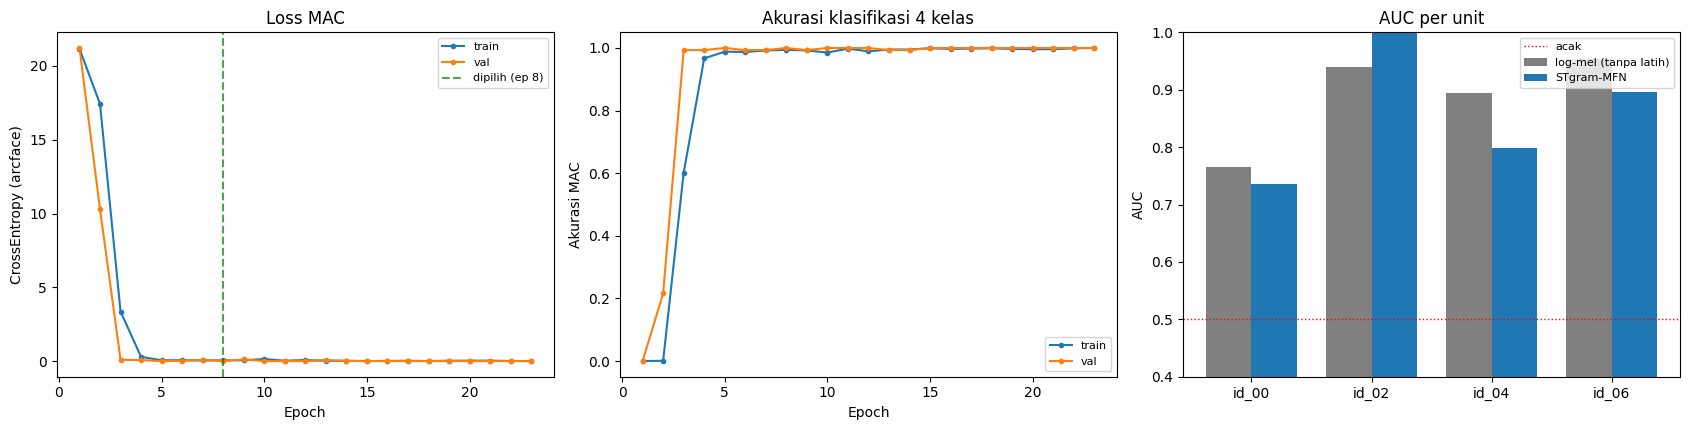

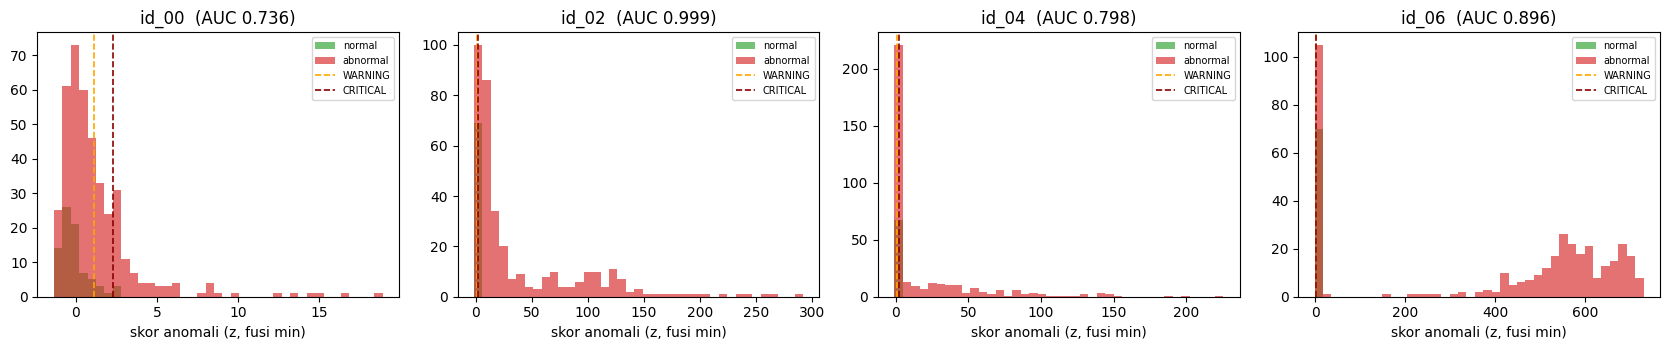

Tersimpan di C:\Users\Frederick\audiax_model\experiments:
  - stgram_mfn.pt
  - results_stgram_mfn.csv
  - backends_stgram_mfn.csv
  - results_stgram_mfn.md
  - training_stgram_mfn.png
  - scores_stgram_mfn.png


In [17]:
import matplotlib.pyplot as plt

EXP_DIR = REPO_ROOT / "experiments"
ep = range(1, len(HIST["train_loss"]) + 1)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))
ax[0].plot(ep, HIST["train_loss"], marker="o", ms=3, label="train")
ax[0].plot(ep, HIST["val_loss"], marker="o", ms=3, label="val")
ax[0].axvline(BEST_EPOCH, color="green", ls="--", alpha=.7, label=f"dipilih (ep {BEST_EPOCH})")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel(f"CrossEntropy ({CFG.margin_type})")
ax[0].set_title("Loss MAC"); ax[0].legend(fontsize=8)

ax[1].plot(ep, HIST["train_acc"], marker="o", ms=3, label="train")
ax[1].plot(ep, HIST["val_acc"], marker="o", ms=3, label="val")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Akurasi MAC")
ax[1].set_title(f"Akurasi klasifikasi {N_CLASSES} kelas"); ax[1].legend(fontsize=8)

x = np.arange(len(UNIT_RES)); wid = 0.38
ax[2].bar(x - wid / 2, COMPARE["baseline_auc"], wid, label="log-mel (tanpa latih)", color="gray")
ax[2].bar(x + wid / 2, COMPARE["stgram_auc"], wid, label="STgram-MFN", color="tab:blue")
ax[2].axhline(0.5, color="red", ls=":", lw=1, label="acak")
ax[2].set_xticks(x); ax[2].set_xticklabels(UNIT_RES["unit"])
ax[2].set_ylim(0.4, 1.0); ax[2].set_ylabel("AUC")
ax[2].set_title("AUC per unit"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig(EXP_DIR / f"training_{RUN_TAG}.png", dpi=150); plt.show()

fig, axes = plt.subplots(1, len(RAW_SCORES), figsize=(4.2 * len(RAW_SCORES), 3.6), squeeze=False)
for a, unit in zip(axes[0], sorted(RAW_SCORES)):
    y, fused = RAW_SCORES[unit]["y"], RAW_SCORES[unit]["fused"]
    bins = np.linspace(np.percentile(fused, 0.5), np.percentile(fused, 99.5), 40)
    a.hist(fused[y == 0], bins=bins, alpha=.65, label="normal", color="tab:green")
    a.hist(fused[y == 1], bins=bins, alpha=.65, label="abnormal", color="tab:red")
    a.axvline(THRESHOLDS[unit]["warning"], color="orange", ls="--", lw=1.2, label="WARNING")
    a.axvline(THRESHOLDS[unit]["critical"], color="darkred", ls="--", lw=1.2, label="CRITICAL")
    a.set_title(f"{unit}  (AUC {UNIT_RES.set_index('unit').loc[unit, 'auc']:.3f})")
    a.set_xlabel("skor anomali (z, fusi min)"); a.legend(fontsize=7)
plt.tight_layout(); plt.savefig(EXP_DIR / f"scores_{RUN_TAG}.png", dpi=150); plt.show()

torch.save({
    "model_state": {k: v.detach().cpu() for k, v in MODEL.state_dict().items()},
    "config": asdict(CFG), "n_classes": N_CLASSES, "unit_order": UNIT_ORDER,
    "unit_to_classes": UNIT_TO_CLASSES, "feat_shape": FEAT_SHAPE,
    "selected_epoch": BEST_EPOCH, "thresholds": THRESHOLDS,
    "auc_hmean": S_AUC, "pauc_hmean": S_PAUC,
}, EXP_DIR / f"{RUN_TAG}.pt")

COMPARE.to_csv(EXP_DIR / f"results_{RUN_TAG}.csv", index=False)
BACKEND_RES.to_csv(EXP_DIR / f"backends_{RUN_TAG}.csv", index=False)

with open(EXP_DIR / f"results_{RUN_TAG}.md", "w", encoding="utf-8") as f:
    f.write("# AUDIAX -- STgram-MFN pada MIMII (`Dataset/`)\n\n")
    f.write(f"Dilatih dengan objektif MAC ({N_CLASSES} kelas, "
            f"{CFG.margin_type} s={CFG.arcface_scale} m={CFG.arcface_margin}, "
            f"{CFG.n_subcenters} sub-pusat) memakai **klip normal saja**. "
            f"Checkpoint epoch {BEST_EPOCH} dipilih lewat val loss MAC -- "
            f"label anomali tidak pernah menyentuh training.\n\n")
    f.write(f"Parameter: {_n_par:,} (~{_n_par * 4 / 1e6:.1f} MB)\n\n")
    f.write("## Hasil utama (rata-rata harmonik lintas unit)\n\n")
    f.write("| Encoder | AUC | pAUC (p=0.1) |\n|---|---|---|\n")
    f.write(f"| log-mel statistik, tanpa training | {B_AUC:.4f} | {B_PAUC:.4f} |\n")
    f.write(f"| **STgram-MFN** | **{S_AUC:.4f}** | **{S_PAUC:.4f}** |\n")
    f.write(f"| delta | {S_AUC - B_AUC:+.4f} | {S_PAUC - B_PAUC:+.4f} |\n\n")
    f.write("## Per unit\n\n" + COMPARE.round(4).to_markdown(index=False) + "\n\n")
    f.write("## Per backend (AUC)\n\n" + pivot_auc.round(4).to_markdown() + "\n\n")
    f.write("## Titik kerja\n\n" + OPS.to_markdown(index=False) + "\n")

print(f"Tersimpan di {EXP_DIR}:")
for n in (f"{RUN_TAG}.pt", f"results_{RUN_TAG}.csv", f"backends_{RUN_TAG}.csv",
          f"results_{RUN_TAG}.md", f"training_{RUN_TAG}.png", f"scores_{RUN_TAG}.png"):
    print("  -", n)


## 17. Uji eksternal opsional: DCASE2021 `fan/`

Representasi diuji pada dataset DCASE yang sama sekali asing untuk mengukur generalisasi, bukan angka produk.


In [18]:
DCASE_ROOT = REPO_ROOT / CFG.dcase_dir


def build_dcase_manifest(root: Path) -> pd.DataFrame:
    rows = []
    for split_dir, is_train in (("train", True), ("source_test", False), ("target_test", False)):
        d = root / split_dir
        if not d.is_dir():
            continue
        for wav in sorted(d.glob("*.wav")):
            parts = wav.stem.split("_")
            rows.append({
                "path": str(wav),
                "unit": f"{parts[0]}_{parts[1]}_{parts[2]}",
                "section": f"{parts[0]}_{parts[1]}",
                "domain": parts[2],
                "is_anomaly": int("anomaly" in wav.stem),
                "is_train": is_train,
            })
    return pd.DataFrame(rows)


def evaluate_dcase(calib_df, emb_calib, test_df, emb_test, cfg: Config) -> pd.DataFrame:
    rows = []
    for section in sorted(test_df["section"].unique()):
        bank = emb_calib[(calib_df["section"] == section).to_numpy()]
        stats = fit_calibration(bank, cfg)
        for domain in ("source", "target"):
            m = ((test_df["section"] == section) & (test_df["domain"] == domain)).to_numpy()
            if not m.any():
                continue
            y = test_df.loc[m, "is_anomaly"].to_numpy()
            _, fused = score_clips(emb_test[m], bank, stats, cfg)
            auc, pauc = auc_pauc(y, fused)
            rows.append({"section": section, "domain": domain,
                         "n": int(m.sum()), "auc": auc, "pauc": pauc})
    return pd.DataFrame(rows)


if not DCASE_ROOT.is_dir():
    print(f"Lewati: {DCASE_ROOT} tidak ada.")
else:
    DC = build_dcase_manifest(DCASE_ROOT)
    DC_TRAIN = DC[DC["is_train"] & (DC["domain"] == "source")]
    _n_dc = min(CFG.n_calib_clips, DC_TRAIN.groupby("section").size().min())
    DC_CALIB = (DC_TRAIN.groupby("section", group_keys=False)
                .sample(n=int(_n_dc), random_state=CFG.split_seed).reset_index(drop=True))
    DC_TEST = DC[~DC["is_train"]].reset_index(drop=True)

    assert set(DC["path"]).isdisjoint(set(TRAIN_DF["path"])), "BOCOR: klip DCASE ada di training!"

    EXT_CFG = Config(**{**asdict(CFG), "backends": ("cosine", "knn", "maha")})
    print(f"DCASE: {len(DC_CALIB)} klip kalibrasi ({_n_dc}/section), "
          f"{len(DC_TEST)} klip test, {DC['section'].nunique()} section\n")

    dc_res = {}
    for tag, embed_fn in (("stgram", lambda d: extract_embeddings(MODEL, d, CFG)),
                          ("logmel", lambda d: logmel_stat_embeddings(d, CFG))):
        dc_res[tag] = evaluate_dcase(DC_CALIB, embed_fn(DC_CALIB),
                                     DC_TEST, embed_fn(DC_TEST), EXT_CFG)

    EXT = dc_res["logmel"][["section", "domain"]].copy()
    EXT["logmel_auc"] = dc_res["logmel"]["auc"].to_numpy()
    EXT["stgram_auc"] = dc_res["stgram"]["auc"].to_numpy()
    EXT["delta_auc"] = EXT["stgram_auc"] - EXT["logmel_auc"]
    EXT["logmel_pauc"] = dc_res["logmel"]["pauc"].to_numpy()
    EXT["stgram_pauc"] = dc_res["stgram"]["pauc"].to_numpy()
    display(EXT.round(4))

    E_B, E_S = hmean(EXT["logmel_auc"]), hmean(EXT["stgram_auc"])
    print("=" * 74)
    print("UJI EKSTERNAL DCASE  (tidak pernah dilihat saat training)")
    print(f"  log-mel tanpa latih : AUC {E_B:.4f}   pAUC {hmean(EXT['logmel_pauc']):.4f}")
    print(f"  STgram-MFN          : AUC {E_S:.4f}   pAUC {hmean(EXT['stgram_pauc']):.4f}")
    print(f"  delta               : {E_S - E_B:+.4f}")
    print("=" * 74)
    print("Representasinya berpindah ke dataset asing." if E_S > E_B else
          "Belum berpindah: yang dipelajari masih khas-MIMII. "
          "Jangan mengutip angka MIMII sebagai bukti generalisasi.")
    EXT.to_csv(EXP_DIR / f"external_dcase_{RUN_TAG}.csv", index=False)


DCASE: 600 klip kalibrasi (200/section), 1200 klip test, 3 section



,section,domain,logmel_auc,stgram_auc,delta_auc,logmel_pauc,stgram_pauc
0,section_00,source,0.5919,0.3541,-0.2378,0.5016,0.4926
1,section_00,target,0.6313,0.7106,0.0793,0.5047,0.5932
2,section_01,source,0.6130,0.4371,-0.1759,0.5089,0.4911
3,section_01,target,0.5481,0.5589,0.0108,0.4811,0.5053
4,section_02,source,0.6960,0.5583,-0.1377,0.5326,0.5047
5,section_02,target,0.6601,0.5250,-0.1351,0.5347,0.5158


UJI EKSTERNAL DCASE  (tidak pernah dilihat saat training)
  log-mel tanpa latih : AUC 0.6198   pAUC 0.5099
  STgram-MFN          : AUC 0.4998   pAUC 0.5150
  delta               : -0.1199
Belum berpindah: yang dipelajari masih khas-MIMII. Jangan mengutip angka MIMII sebagai bukti generalisasi.


## 18. Ringkasan

Ringkasan pipeline dari front-end sampai ambang keputusan, beserta batasan rulebook yang tetap dipatuhi.
